# STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# STEP 2: LOAD DATA

In [2]:
df = pd.read_csv("../datasets/fullcleaned_house_data.csv")

# STEP 3: REMOVE DATA LEAKAGE

In [3]:
df = df.drop(columns=["area_rate"], errors="ignore")

# STEP 4: FEATURE ENGINEERING

In [4]:
df["total_rooms"] = df["beds"] + df["bathrooms"]
df["area_log"] = np.log1p(df["area"])

# STEP 5: TARGET ENCODING

In [5]:
locality_mean = df.groupby("locality")["rent"].mean()
df["locality_encoded"] = df["locality"].map(locality_mean)

city_mean = df.groupby("city")["rent"].mean()
df["city_encoded"] = df["city"].map(city_mean)

df = df.drop(["locality", "city", "area"], axis=1)

# STEP 6: FEATURE & TARGET

In [6]:
X = df.drop("rent", axis=1)
y = np.log1p(df["rent"])

# STEP 7: ENCODING

In [7]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["furnishing", "house_type"]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

pickle.dump(encoders, open("../model/encoders.pkl", "wb"))

# STEP 8: TRAIN TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 9: MODELS

In [9]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(max_depth=10),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


# STEP 10: TRAIN + EVALUATE

In [10]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_test)

    # reverse log
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)  
    r2 = r2_score(y_actual, y_pred)

    results.append([name, mae, mse, rmse, r2])

    print(f"\n{name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)


Linear Regression
MAE: 19287.55344769748
MSE: 4078106405.1542377
RMSE: 63860.05328179924
R2: 0.4558321836995757

Decision Tree
MAE: 16219.190205452944
MSE: 1775469012.0628276
RMSE: 42136.31464737783
R2: 0.763087815957377

Random Forest
MAE: 13520.812745783182
MSE: 1034124952.946505
RMSE: 32157.813248828115
R2: 0.8620100945096857

XGBoost
MAE: 14036.385412918893
MSE: 1304526761.4357367
RMSE: 36118.2330885072
R2: 0.8259286520384206


# STEP 11: RESULTS TABLE

In [11]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print("\nFinal Comparison:\n")
print(results_df)


Final Comparison:

               Model           MAE           MSE          RMSE        R2
2      Random Forest  13520.812746  1.034125e+09  32157.813249  0.862010
3            XGBoost  14036.385413  1.304527e+09  36118.233089  0.825929
1      Decision Tree  16219.190205  1.775469e+09  42136.314647  0.763088
0  Linear Regression  19287.553448  4.078106e+09  63860.053282  0.455832


# STEP 12: VISUALIZATION (MODEL COMPARISON)

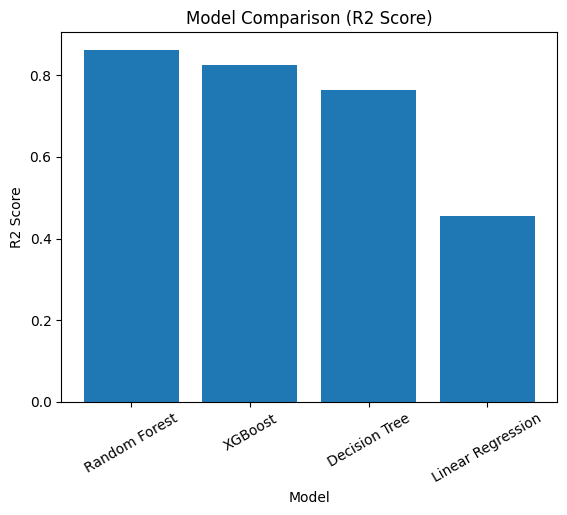

In [12]:
plt.figure()
plt.bar(results_df["Model"], results_df["R2"])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

# STEP 13: BEST MODEL

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

print("\nBest Model:", best_model_name)


Best Model: Random Forest


# STEP 14: CROSS VALIDATION

In [14]:
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="r2")
print("\nCross Validation R2:", cv_scores.mean())


Cross Validation R2: 0.8790284902796655


# STEP 15: PREDICTION GRAPH (ACTUAL vs PREDICTED)

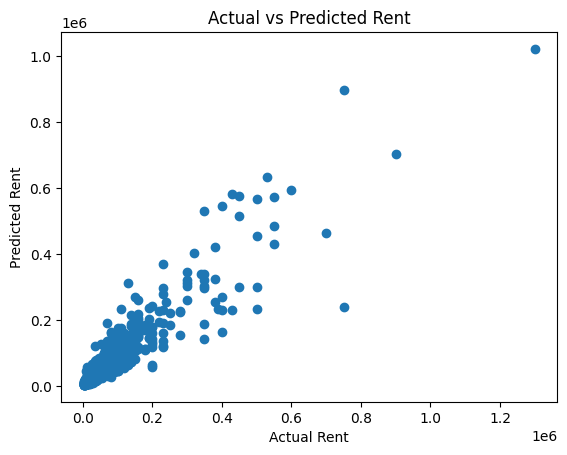

In [15]:
y_pred_log = best_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

plt.figure()
plt.scatter(y_actual, y_pred)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent")
plt.show()

# STEP 16: SAVE MODEL

In [16]:
pickle.dump(best_model, open("../model/house_model.pkl", "wb"))
pickle.dump(locality_mean, open("../model/locality_mean.pkl", "wb"))
pickle.dump(city_mean, open("../model/city_mean.pkl", "wb"))

print("\nModel Saved Successfully")


Model Saved Successfully
